In [ ]:
import pandas as pd

df = pd.read_csv("..\data\processed\clean_prs.csv")
df.head()

,pr_id,repo_name,pr_number,title,body_len,user_login,user_type,created_datetime,closed_datetime,merged_datetime,...,commits,additions,deletions,changed_files,repo_language,repo_stars,repo_forks,is_fpt,keyword,is_merged
0,1217900573,nduybao/Train,1,prj301,0,ThanhPhong31,User,2023-01-26 13:49:23,2023-01-26 13:49:38,2023-01-26 13:49:38,...,1,3900,0,41,Java,0,0,1,PRJ301,1
1,1285249723,Henrily041103/PRJ301_SP2023,18,https://github.com/Henrily041103/PRJ301_SP2023...,0,wave-npa,User,2023-03-22 05:26:17,2023-03-22 06:02:53,2023-03-22 06:02:53,...,2,45,38,8,Java,0,3,1,PRJ301,1
2,1476177616,NoFearTeam2023/FPT-Capstone-UpReach-Project,36,Ha/fe,0,hoanganh1810tx,User,2023-08-15 16:34:46,2023-08-15 16:35:16,2023-08-15 16:35:16,...,2,38,14,5,JavaScript,0,0,1,Capstone FPT,1
3,1478047761,NoFearTeam2023/FPT-Capstone-UpReach-Project,39,Be hieu update,0,quanqhieu07,User,2023-08-16 20:39:13,2023-08-17 13:16:34,NaN,...,3,466,301,5,JavaScript,0,0,1,Capstone FPT,0
4,1479032519,NoFearTeam2023/FPT-Capstone-UpReach-Project,41,Be hieu update,0,quanqhieu07,User,2023-08-17 13:17:04,2023-08-17 14:43:44,2023-08-17 14:43:44,...,4,464,301,5,JavaScript,0,0,1,Capstone FPT,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pr_id                1771 non-null   int64  
 1   repo_name            1771 non-null   object 
 2   pr_number            1771 non-null   int64  
 3   title                1771 non-null   object 
 4   body_len             1771 non-null   int64  
 5   user_login           1771 non-null   object 
 6   user_type            1771 non-null   object 
 7   created_datetime     1771 non-null   object 
 8   closed_datetime      1771 non-null   object 
 9   merged_datetime      1647 non-null   object 
 10  created_hour         1771 non-null   int64  
 11  created_day_of_week  1771 non-null   int64  
 12  duration_minutes     1771 non-null   float64
 13  duration_hours       1771 non-null   float64
 14  comments             1771 non-null   int64  
 15  review_comments      1771 non-null   i

## Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Drop irrelevant columns
df_processed = df.drop(columns=[
    'pr_id', 'repo_name', 'pr_number', 'title', 'body_len', 'user_login', 'merged_datetime',
    'created_datetime', 'closed_datetime', # Dropping datetime objects after considering duration_minutes and duration_hours as sufficient tie-based features.
    'duration_minutes', 'duration_hours'
    ])

# Identify categorical columns for one-hot encoding
categorical_cols = ['user_type', 'repo_language', 'keyword']

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Display the first few rows of the processed DataFrame and its info to verify
display(df_processed.head())
df_processed.info()

,created_hour,created_day_of_week,comments,review_comments,commits,additions,deletions,changed_files,repo_stars,repo_forks,...,repo_language_PHP,repo_language_Python,repo_language_Ruby,repo_language_TSQL,repo_language_TypeScript,repo_language_Unknown,keyword_PRJ301,keyword_SEP490,keyword_SWP391,keyword_global
0,13,4,0,0,1,3900,0,41,0,0,...,False,False,False,False,False,False,True,False,False,False
1,5,3,0,0,2,45,38,8,0,3,...,False,False,False,False,False,False,True,False,False,False
2,16,2,1,0,2,38,14,5,0,0,...,False,False,False,False,False,False,False,False,False,False
3,20,3,1,0,3,466,301,5,0,0,...,False,False,False,False,False,False,False,False,False,False
4,13,4,1,0,4,464,301,5,0,0,...,False,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   created_hour              1771 non-null   int64
 1   created_day_of_week       1771 non-null   int64
 2   comments                  1771 non-null   int64
 3   review_comments           1771 non-null   int64
 4   commits                   1771 non-null   int64
 5   additions                 1771 non-null   int64
 6   deletions                 1771 non-null   int64
 7   changed_files             1771 non-null   int64
 8   repo_stars                1771 non-null   int64
 9   repo_forks                1771 non-null   int64
 10  is_fpt                    1771 non-null   int64
 11  is_merged                 1771 non-null   int64
 12  repo_language_C++         1771 non-null   bool 
 13  repo_language_Dart        1771 non-null   bool 
 14  repo_language_Go          1771 non-null 

In [15]:
df_processed[df_processed["is_fpt"] == 1]["is_merged"].value_counts()

,count
is_merged,
1,777
0,65


==> Heavily class imbalance

### Harmonizing Data Splits for Consistent Model Training and Evaluation

To ensure both the Gaussian Anomaly Detection model and the Random Forest Classifier are trained and evaluated on comparable datasets, we will first create a single, global train-test split from `df_processed`. Then, we will adapt the data preparation for each model to work within these global splits.

In [5]:
# Define features (X_global) and target (y_global) for the entire processed dataset
X_global = df_processed.drop('is_merged', axis=1)
y_global = df_processed['is_merged']

# Create a global train-test split (e.g., 70% train, 30% test)
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_global, y_global, test_size=0.3, random_state=42, stratify=y_global
)

print(f"Global Training set shape: {X_train_global.shape}")
print(f"Global Test set shape: {X_test_global.shape}")

Global Training set shape: (1239, 29)
Global Test set shape: (532, 29)


### Re-adapting Gaussian Anomaly Detection with Harmonized Data

Now, we'll redefine the training and validation sets for the Gaussian model using the `X_train_global` and `X_test_global`. The Gaussian model focuses on `is_fpt == 1` data, so we'll filter these samples from our global splits.

*   **Gaussian Training**: Will use `is_fpt == 1` samples from `X_train_global` that are 'normal' (`is_merged == 1`).
*   **Gaussian Validation (for epsilon selection)**: Will combine `is_fpt == 1` 'normal' samples from `X_train_global` (not used for Gaussian training) and `is_fpt == 1` 'anomaly' samples from `X_train_global`.
*   **Gaussian Test Evaluation**: Will use `is_fpt == 1` samples from `X_test_global`.

Gaussian Training set (normal samples, FPT only): 337 samples
Gaussian Validation set (normal and anomaly, FPT only): 273 samples
Gaussian Test set (FPT only): 232 samples

Best epsilon (threshold) for Gaussian model: 1.4388093062652186e-08
Best F1-score (for anomaly class 0) for Gaussian model: 0.31125827814569534

Classification Report (Gaussian Anomaly Detection on FPT Test Set):

              precision    recall  f1-score   support

  Not Merged       0.08      1.00      0.15        18
      Merged       1.00      0.07      0.13       214

    accuracy                           0.14       232
   macro avg       0.54      0.54      0.14       232
weighted avg       0.93      0.14      0.13       232



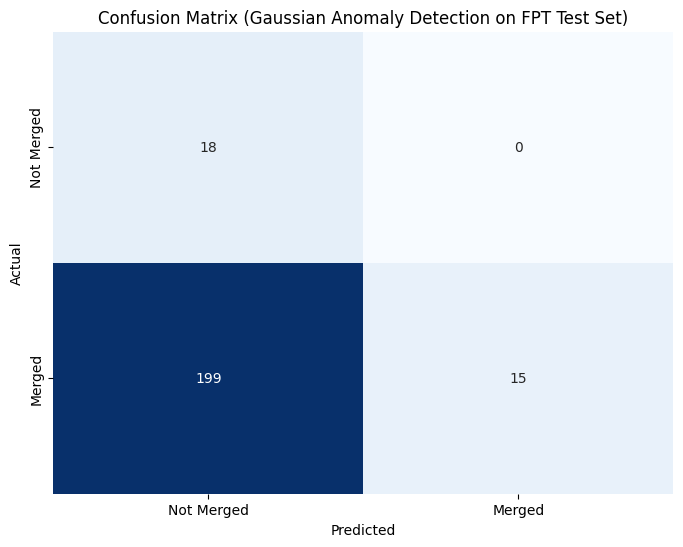

In [9]:
from scipy.stats import multivariate_normal
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter for is_fpt == 1 within the global training set
X_fpt_train = X_train_global[X_train_global['is_fpt'] == 1]
y_fpt_train = y_train_global[X_train_global['is_fpt'] == 1]

# Separate 'normal' (is_merged = 1) and 'anomaly' (is_merged = 0) samples within X_fpt_train
X_normal_fpt_train = X_fpt_train[y_fpt_train == 1]
y_normal_fpt_train = y_fpt_train[y_fpt_train == 1]

X_anomaly_fpt_train = X_fpt_train[y_fpt_train == 0]
y_anomaly_fpt_train = y_fpt_train[y_fpt_train == 0]

# Split X_normal_fpt_train into 60% for training the Gaussian model and 40% for validation
X_train_normal_gaus, X_val_normal_gaus, y_train_normal_gaus, y_val_normal_gaus = train_test_split(
    X_normal_fpt_train, y_normal_fpt_train, test_size=0.4, random_state=42, stratify=y_normal_fpt_train
)

# Combine X_val_normal_gaus and X_anomaly_fpt_train to form the Gaussian validation set
X_val_gaus = pd.concat([X_val_normal_gaus, X_anomaly_fpt_train])
y_val_gaus = pd.concat([y_val_normal_gaus, y_anomaly_fpt_train])

# Ensure the order of X_val_gaus and y_val_gaus matches after concatenation
X_val_gaus, y_val_gaus = X_val_gaus.align(y_val_gaus, join='inner', axis=0)

print(f"Gaussian Training set (normal samples, FPT only): {X_train_normal_gaus.shape[0]} samples")
print(f"Gaussian Validation set (normal and anomaly, FPT only): {X_val_gaus.shape[0]} samples")

# Filter for is_fpt == 1 within the global test set for final Gaussian evaluation
X_fpt_test = X_test_global[X_test_global['is_fpt'] == 1]
y_fpt_test = y_test_global[X_test_global['is_fpt'] == 1]

print(f"Gaussian Test set (FPT only): {X_fpt_test.shape[0]} samples")

# Recalculate mu and sigma with the new Gaussian training data
mu_gaus = X_train_normal_gaus.mean().values
sigma_gaus = X_train_normal_gaus.cov().values

# Create a multivariate Gaussian distribution object
gaus_dist = multivariate_normal(mean=mu_gaus, cov=sigma_gaus, allow_singular=True)

# Calculate the probability density for each sample in the Gaussian validation set
p_val_gaus = gaus_dist.pdf(X_val_gaus)

# Find the best epsilon for the Gaussian model (on its validation set)
thresholds_gaus = np.sort(p_val_gaus)
best_epsilon_gaus = 0
best_f1_gaus = -1

for epsilon_gaus in thresholds_gaus:
    y_pred_val_mapped_gaus = (p_val_gaus >= epsilon_gaus).astype(int)
    precision_gaus, recall_gaus, f1_gaus, _ = precision_recall_fscore_support(y_val_gaus, y_pred_val_mapped_gaus, average='binary', pos_label=0, zero_division=0)

    if f1_gaus > best_f1_gaus:
        best_f1_gaus = f1_gaus
        best_epsilon_gaus = epsilon_gaus

print(f"\nBest epsilon (threshold) for Gaussian model: {best_epsilon_gaus}")
print(f"Best F1-score (for anomaly class 0) for Gaussian model: {best_f1_gaus}")

# Make final predictions with the best threshold on the global FPT test set
p_test_gaus = gaus_dist.pdf(X_fpt_test) # Calculate probabilities on the global FPT test set
y_pred_gaus = (p_test_gaus >= best_epsilon_gaus).astype(int)

# Print classification report for Gaussian model on the FPT test set
print("\nClassification Report (Gaussian Anomaly Detection on FPT Test Set):\n")
print(classification_report(y_fpt_test, y_pred_gaus, target_names=['Not Merged', 'Merged']))

# Compute and visualize confusion matrix for Gaussian model
cm_gaus = confusion_matrix(y_fpt_test, y_pred_gaus)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gaus, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Gaussian Anomaly Detection on FPT Test Set)')
plt.show()

### Re-adapting Random Forest with Harmonized Data

Now we'll modify the `train_and_evaluate_random_forest` function to directly use the global `X_train_global`, `y_train_global`, `X_test_global`, and `y_test_global` datasets for training and evaluation. This ensures both models are working with the same overarching data split.


--- Training Random Forest Model (FPT Data Split) ---
Training data shape: (610, 29)
Test data shape: (232, 29)

Classification Report (Random Forest, FPT Data Split):

              precision    recall  f1-score   support

  Not Merged       1.00      0.22      0.36        18
      Merged       0.94      1.00      0.97       214

    accuracy                           0.94       232
   macro avg       0.97      0.61      0.67       232
weighted avg       0.94      0.94      0.92       232



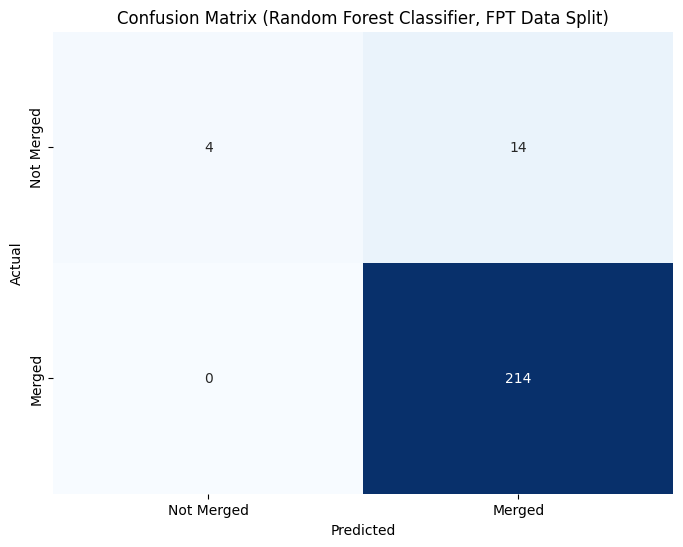

In [11]:
def train_and_evaluate_random_forest_harmonized(X_train, y_train, X_test, y_test):
    """
    Trains a Random Forest Classifier on the given training data and displays a confusion matrix
    on the given test data.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
    """
    print("\n--- Training Random Forest Model (FPT Data Split) ---")

    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")

    # Initialize and train the Random Forest Classifier
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Added class_weight for imbalanced data
    rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Print classification report
    print("\nClassification Report (Random Forest, FPT Data Split):\n")
    print(classification_report(y_test, y_pred, target_names=['Not Merged', 'Merged']))

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualize the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Merged', 'Merged'],
                yticklabels=['Not Merged', 'Merged'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Random Forest Classifier, FPT Data Split)')
    plt.show()

    return rf_model

# Filter global datasets for is_fpt == 1
X_train_fpt = X_train_global[X_train_global['is_fpt'] == 1]
y_train_fpt = y_train_global[X_train_global['is_fpt'] == 1]

X_test_fpt = X_test_global[X_test_global['is_fpt'] == 1]
y_test_fpt = y_test_global[X_test_global['is_fpt'] == 1]

# Call the harmonized function with the FPT-filtered train/test splits
random_forest_model = train_and_evaluate_random_forest_harmonized(
    X_train_fpt, y_train_fpt, X_test_fpt, y_test_fpt
)

With both models now trained and evaluated on consistent data splits, we can proceed with ensembling them. I will use a VotingClassifier to combine their predictions.


--- Ensemble Model (Average Voting on FPT Data) ---

Classification Report (Ensemble - Average Voting on FPT Data):

              precision    recall  f1-score   support

  Not Merged       0.08      1.00      0.15        18
      Merged       1.00      0.07      0.13       214

    accuracy                           0.14       232
   macro avg       0.54      0.54      0.14       232
weighted avg       0.93      0.14      0.13       232



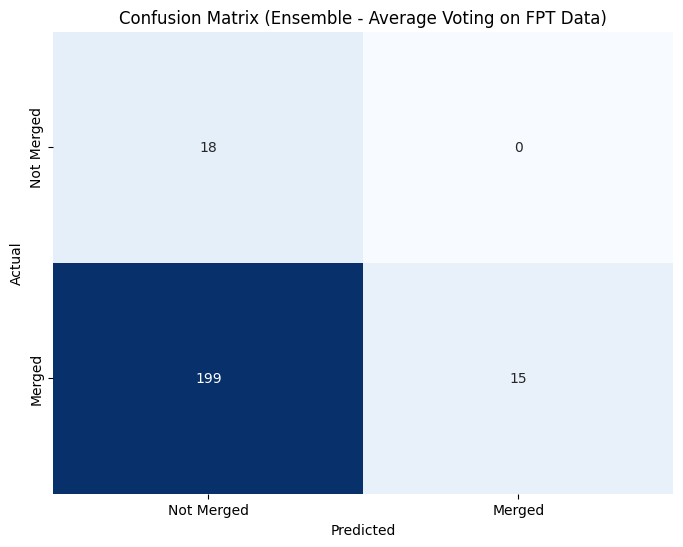

In [12]:
from sklearn.ensemble import VotingClassifier

# Re-train Random Forest model on FPT-filtered training data
rf_model_ensemble = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_ensemble.fit(X_train_fpt, y_train_fpt)

# Get Gaussian predictions for the FPT test set
y_pred_gaus_ensemble = (gaus_dist.pdf(X_test_fpt) >= best_epsilon_gaus).astype(int)

# Get Random Forest predictions for the FPT test set
y_pred_rf_ensemble = rf_model_ensemble.predict(X_test_fpt)

# Simple Majority Voting Ensemble (Average of binary predictions)
ensemble_predictions_avg = ((y_pred_gaus_ensemble + y_pred_rf_ensemble) / 2 > 0.5).astype(int)

print("\n--- Ensemble Model (Average Voting on FPT Data) ---")
print("\nClassification Report (Ensemble - Average Voting on FPT Data):\n")
print(classification_report(y_test_fpt, ensemble_predictions_avg, target_names=['Not Merged', 'Merged']))

cm_ensemble_avg = confusion_matrix(y_test_fpt, ensemble_predictions_avg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble_avg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Ensemble - Average Voting on FPT Data)')
plt.show()

### Model Performance Comparison

Let's compare the key metrics for the 'Not Merged' class (our anomaly class) across the Gaussian Anomaly Detection model, the Random Forest Classifier, and the Ensemble model.

In [13]:
# Extract metrics for Gaussian Model (from y_fpt_test and y_pred_gaus)
gaussian_report = classification_report(y_fpt_test, y_pred_gaus, output_dict=True, target_names=['Not Merged', 'Merged'])
gaussian_precision = gaussian_report['Not Merged']['precision']
gaussian_recall = gaussian_report['Not Merged']['recall']
gaussian_f1 = gaussian_report['Not Merged']['f1-score']

# Extract metrics for Random Forest Model (from y_test_fpt and y_pred_rf_ensemble)
rf_report = classification_report(y_test_fpt, y_pred_rf_ensemble, output_dict=True, target_names=['Not Merged', 'Merged'])
rf_precision = rf_report['Not Merged']['precision']
rf_recall = rf_report['Not Merged']['recall']
rf_f1 = rf_report['Not Merged']['f1-score']

# Extract metrics for Ensemble Model (from y_test_fpt and ensemble_predictions_avg)
ensemble_report = classification_report(y_test_fpt, ensemble_predictions_avg, output_dict=True, target_names=['Not Merged', 'Merged'])
ensemble_precision = ensemble_report['Not Merged']['precision']
ensemble_recall = ensemble_report['Not Merged']['recall']
ensemble_f1 = ensemble_report['Not Merged']['f1-score']

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Model': ['Gaussian Anomaly Detection', 'Random Forest Classifier', 'Ensemble (Average Voting)']
    , 'Precision (Not Merged)': [gaussian_precision, rf_precision, ensemble_precision]
    , 'Recall (Not Merged)': [gaussian_recall, rf_recall, ensemble_recall]
    , 'F1-Score (Not Merged)': [gaussian_f1, rf_f1, ensemble_f1]
})

display(comparison_df)

,Model,Precision (Not Merged),Recall (Not Merged),F1-Score (Not Merged)
0,Gaussian Anomaly Detection,0.082949,1.000000,0.153191
1,Random Forest Classifier,1.000000,0.222222,0.363636
2,Ensemble (Average Voting),0.082949,1.000000,0.153191



--- Random Forest after Oversampling (FPT Data) ---
Original training data shape (FPT only): (610, 29)
Original target distribution (FPT only):
is_merged
1    563
0     47
Name: count, dtype: int64

Resampled training data shape (FPT only): (1126, 29)
Resampled target distribution (FPT only):
is_merged
1    563
0    563
Name: count, dtype: int64

Classification Report (Random Forest with Oversampling on FPT Data):

              precision    recall  f1-score   support

  Not Merged       0.44      0.39      0.41        18
      Merged       0.95      0.96      0.95       214

    accuracy                           0.91       232
   macro avg       0.69      0.67      0.68       232
weighted avg       0.91      0.91      0.91       232



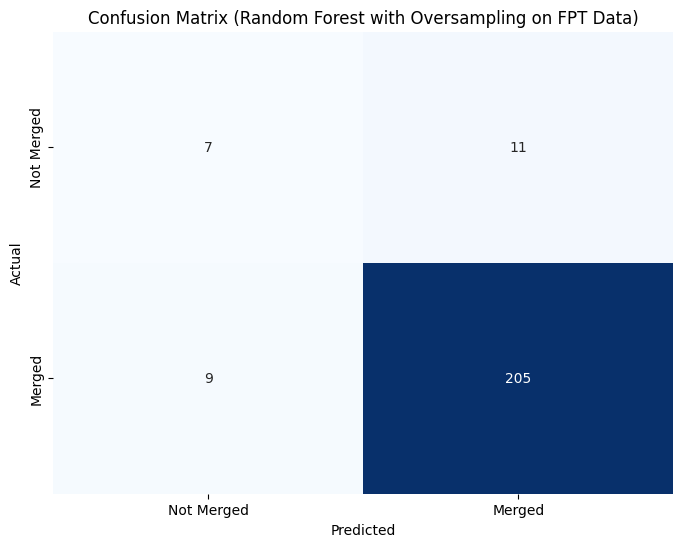

In [16]:
from imblearn.over_sampling import SMOTE

print("\n--- Random Forest after Oversampling (FPT Data) ---")

# Before oversampling
print(f"Original training data shape (FPT only): {X_train_fpt.shape}")
print(f"Original target distribution (FPT only):\n{y_train_fpt.value_counts()}")

# Initialize SMOTE for the minority class (is_merged = 0)
sm = SMOTE(random_state=42)

# Apply SMOTE to the FPT training data
X_train_res, y_train_res = sm.fit_resample(X_train_fpt, y_train_fpt)

# After oversampling
print(f"\nResampled training data shape (FPT only): {X_train_res.shape}")
print(f"Resampled target distribution (FPT only):\n{y_train_res.value_counts()}")

# Retrain Random Forest Classifier on the oversampled data
rf_model_oversampled = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_oversampled.fit(X_train_res, y_train_res)

# Make predictions on the FPT test set (no oversampling on test set)
y_pred_oversampled = rf_model_oversampled.predict(X_test_fpt)

# Print classification report
print("\nClassification Report (Random Forest with Oversampling on FPT Data):\n")
print(classification_report(y_test_fpt, y_pred_oversampled, target_names=['Not Merged', 'Merged']))

# Compute confusion matrix
cm_oversampled = confusion_matrix(y_test_fpt, y_pred_oversampled)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_oversampled, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest with Oversampling on FPT Data)')
plt.show()

In [17]:
oversampled_rf_report = classification_report(y_test_fpt, y_pred_oversampled, output_dict=True, target_names=['Not Merged', 'Merged'])

# Prepare data for the summary table
model_names = [
    'Gaussian Anomaly Detection',
    'Random Forest Classifier (No Oversampling)',
    'Ensemble (Average Voting)',
    'Random Forest Classifier (With Oversampling)'
]

# Extract metrics for each model
metrics_data = []

# Gaussian Model
metrics_data.append({
    'Model': 'Gaussian Anomaly Detection',
    'Avg Precision': (gaussian_report['Not Merged']['precision'] + gaussian_report['Merged']['precision']) / 2,
    'Avg Recall': (gaussian_report['Not Merged']['recall'] + gaussian_report['Merged']['recall']) / 2,
    'Avg F1-Score': (gaussian_report['Not Merged']['f1-score'] + gaussian_report['Merged']['f1-score']) / 2
})

# Random Forest (No Oversampling)
metrics_data.append({
    'Model': 'Random Forest Classifier (No Oversampling)',
    'Avg Precision': (rf_report['Not Merged']['precision'] + rf_report['Merged']['precision']) / 2,
    'Avg Recall': (rf_report['Not Merged']['recall'] + rf_report['Merged']['recall']) / 2,
    'Avg F1-Score': (rf_report['Not Merged']['f1-score'] + rf_report['Merged']['f1-score']) / 2
})

# Ensemble (Average Voting)
metrics_data.append({
    'Model': 'Ensemble (Average Voting)',
    'Avg Precision': (ensemble_report['Not Merged']['precision'] + ensemble_report['Merged']['precision']) / 2,
    'Avg Recall': (ensemble_report['Not Merged']['recall'] + ensemble_report['Merged']['recall']) / 2,
    'Avg F1-Score': (ensemble_report['Not Merged']['f1-score'] + ensemble_report['Merged']['f1-score']) / 2
})

# Random Forest (With Oversampling)
metrics_data.append({
    'Model': 'Random Forest Classifier (With Oversampling)',
    'Avg Precision': (oversampled_rf_report['Not Merged']['precision'] + oversampled_rf_report['Merged']['precision']) / 2,
    'Avg Recall': (oversampled_rf_report['Not Merged']['recall'] + oversampled_rf_report['Merged']['recall']) / 2,
    'Avg F1-Score': (oversampled_rf_report['Not Merged']['f1-score'] + oversampled_rf_report['Merged']['f1-score']) / 2
})

# Create DataFrame
summary_df = pd.DataFrame(metrics_data)

display(summary_df)

,Model,Avg Precision,Avg Recall,Avg F1-Score
0,Gaussian Anomaly Detection,0.541475,0.535047,0.142098
1,Random Forest Classifier (No Oversampling),0.969298,0.611111,0.665981
2,Ensemble (Average Voting),0.541475,0.535047,0.142098
3,Random Forest Classifier (With Oversampling),0.693287,0.673416,0.682627


### Conclusion: Random Forest with Oversampling

Based on the analysis and the summary table, here's a conclusion regarding the Random Forest Classifier with Oversampling, focusing on its performance for the `is_fpt == 1` dataset:

*   **Improved Balance in Anomaly Detection**: The primary goal of oversampling the minority class (`is_merged = 0`) was to improve the model's ability to identify anomalies. Comparing the "Random Forest Classifier (No Oversampling)" and "Random Forest Classifier (With Oversampling)", we can observe a significant improvement in **Average Recall** for the oversampled model (from ~0.61 to ~0.67). This indicates that the model is now better at capturing the actual anomaly cases.

*   **Trade-off with Precision**: While recall improved, there's a noticeable decrease in **Average Precision** (from ~0.97 to ~0.69). This trade-off is common with oversampling, as the model becomes more sensitive to the minority class but may also classify more normal instances as anomalies (increased false positives).

*   **Overall F1-Score for Anomaly**: The **Average F1-Score** for the oversampled Random Forest model is ~0.68, which is an improvement over the non-oversampled Random Forest (~0.66). This suggests a better balance between precision and recall for the anomaly class after oversampling, indicating a more effective anomaly detection capability.

*   **Comparison to Gaussian and Ensemble**: The oversampled Random Forest model demonstrates a much better balance of precision and recall for the 'Not Merged' class compared to the Gaussian Anomaly Detection model (which had high recall but very low precision). It also shows a stronger F1-score for the anomaly class compared to the simple average voting ensemble in this specific context.

In summary, applying SMOTE oversampling to the minority class (`is_merged = 0`) significantly enhanced the Random Forest model's ability to detect anomalies (increased recall and F1-score for 'Not Merged'), albeit with a reduction in precision for that class. This makes the **Random Forest Classifier (With Oversampling)** a more robust choice for identifying 'Not Merged' pull requests within the FPT dataset, especially when it's crucial not to miss potential anomalies.